In [4]:
from stress_risk.utils.data import get_all_behavior
#from tms_risk.utils.data import Subject as TMSSubject
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [8]:
df = get_all_behavior(bids_folder='/Users/mrenke/data/ds-stressrisk')
# df = pd.concat((df, df_tms))

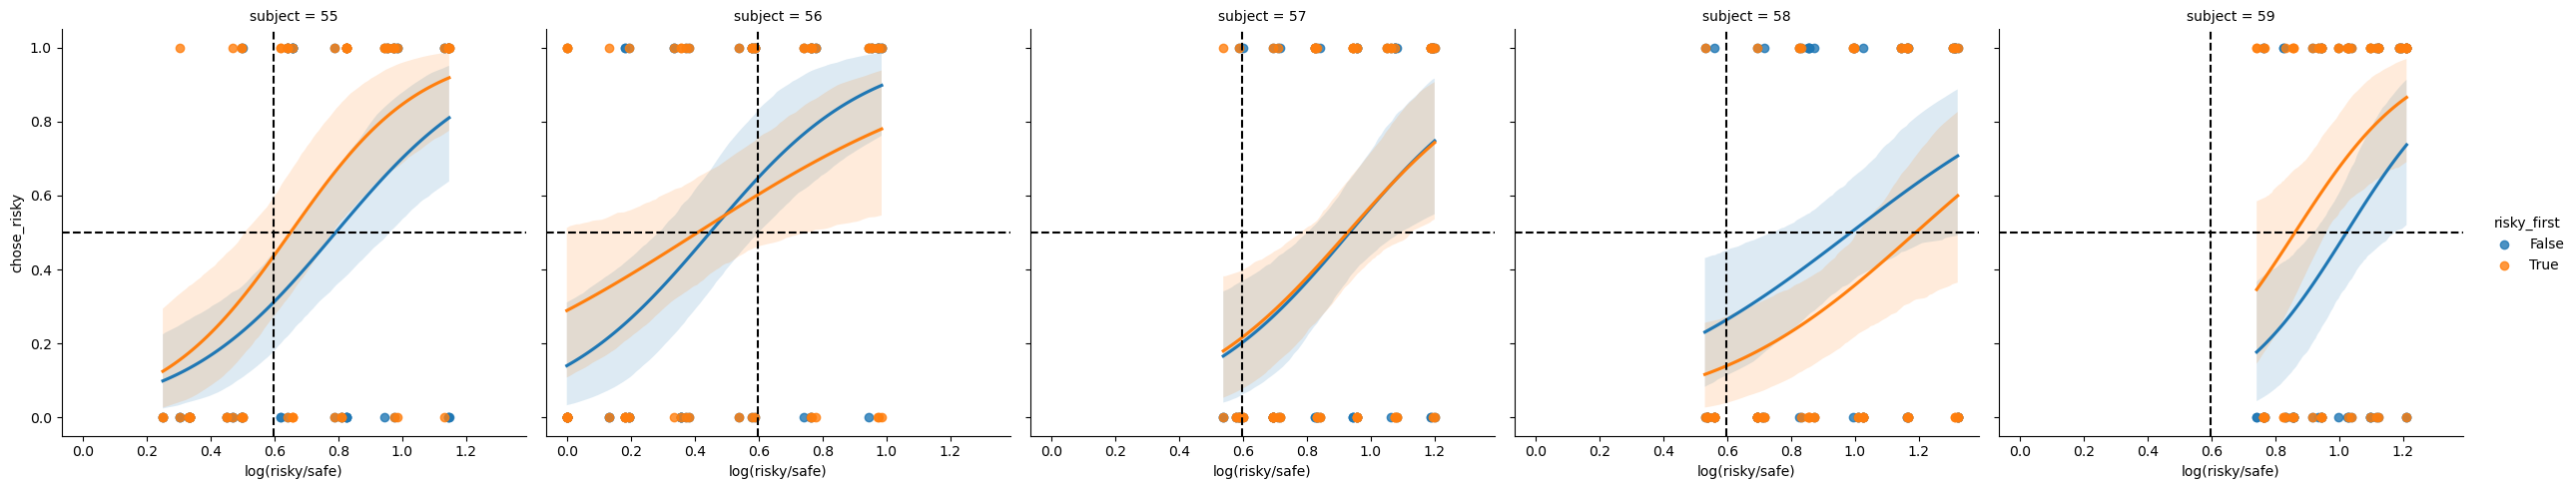

In [23]:
fac = sns.lmplot(x='log(risky/safe)', y='chose_risky', data=df.loc[[55,56,57,58,59]].reset_index(), logistic=True, col='subject', hue='risky_first')

for ax in fac.axes.ravel():
    ax.axhline(.5, c='k', ls='--')
    ax.axvline(np.log(1/.55), c='k', ls='--')

/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_51591/3842034007.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 67)` for the same effect.

  sns.catplot(x='n_safe', y='chose_risky', hue='risky_first',


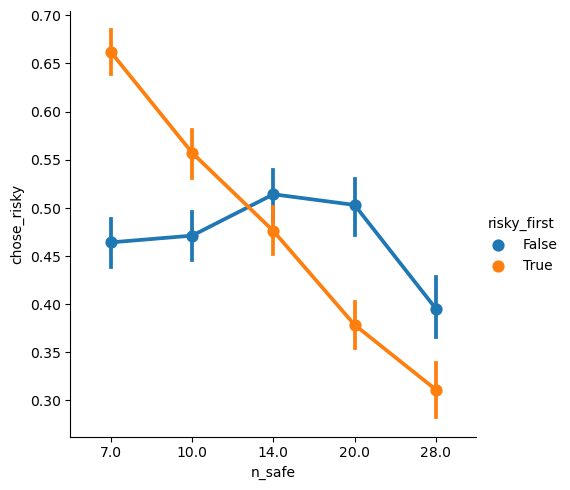

In [11]:
sns.catplot(x='n_safe', y='chose_risky', hue='risky_first',
data=df.groupby(['subject', 'n_safe', 'risky_first']).mean().reset_index(), kind='point', ci=67)

In [12]:
import bambi

In [13]:
df['x'] = df['log(risky/safe)']

In [14]:
model = bambi.Model('chose_risky ~ x + (x|subject)', link='probit', family='bernoulli', data=df.reset_index())

In [15]:
traces = model.fit(init='adapt_diag', target_accept=0.9, draws=1000, tune=1000)

Modeling the probability that chose_risky==1
Auto-assigning NUTS sampler...
Initializing NUTS using adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, x, 1|subject_sigma, 1|subject_offset, x|subject_sigma, x|subject_offset]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 80 seconds.


In [16]:
import scipy.stats as ss
def invprobit(x):
    return ss.norm.ppf(x)

In [17]:
def extract_rnp_precision(trace, model, data, group=False):

    data = data.reset_index()

    if group:
        fake_data = pd.MultiIndex.from_product([data.reset_index()['subject'].unique()[[0]],
                                                [0, 1],
                                                data['n_safe'].unique(),
                                                [False, True]],
                                                names=['subject', 'x', 'n_safe', 'risky_first']
                                                ).to_frame().reset_index(drop=True)
    else:
        fake_data = pd.MultiIndex.from_product([data.reset_index()['subject'].unique(),
                                                [0, 1],
                                                data['n_safe'].unique(),
                                                [False, True]],
                                                names=['subject', 'x', 'n_safe', 'risky_first']
                                                ).to_frame().reset_index(drop=True)

    pred = model.predict(trace, 'mean', fake_data, inplace=False)['posterior']['chose_risky_mean']

    pred = pred.to_dataframe().unstack([0, 1])
    pred = pred.set_index(pd.MultiIndex.from_frame(fake_data))

    # return pred

    pred0 = pred.xs(0, 0, 'x')
    intercept = pd.DataFrame(invprobit(pred0), index=pred0.index, columns=pred0.columns)
    gamma = invprobit(pred.xs(1, 0, 'x')) - intercept

    return intercept, gamma

In [18]:
import arviz as az

array([[<AxesSubplot:title={'center':'Intercept'}>,
        <AxesSubplot:title={'center':'Intercept'}>],
       [<AxesSubplot:title={'center':'x'}>,
        <AxesSubplot:title={'center':'x'}>],
       [<AxesSubplot:title={'center':'1|subject_sigma'}>,
        <AxesSubplot:title={'center':'1|subject_sigma'}>],
       [<AxesSubplot:title={'center':'x|subject_sigma'}>,
        <AxesSubplot:title={'center':'x|subject_sigma'}>],
       [<AxesSubplot:title={'center':'1|subject'}>,
        <AxesSubplot:title={'center':'1|subject'}>],
       [<AxesSubplot:title={'center':'x|subject'}>,
        <AxesSubplot:title={'center':'x|subject'}>]], dtype=object)

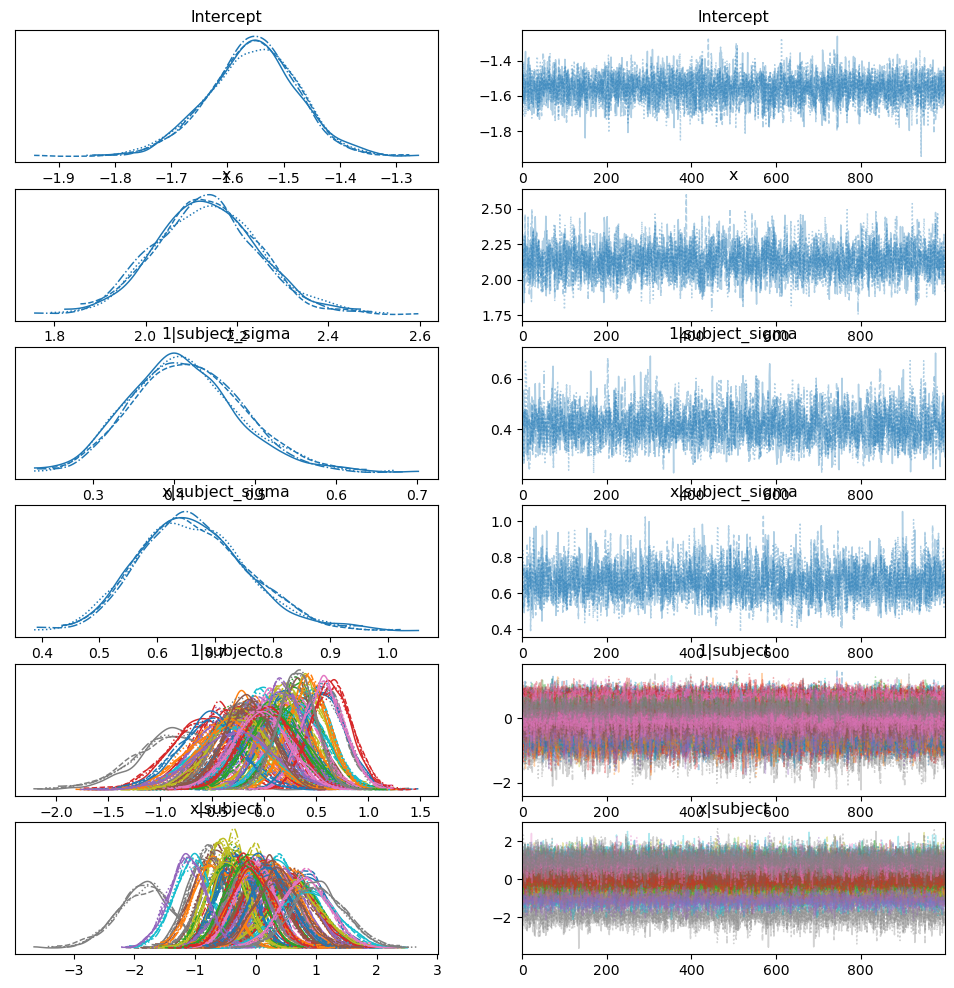

In [19]:
az.plot_trace(traces)

In [24]:
intercept, gamma = extract_rnp_precision(traces, model, df, False)

/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/pandas/core/internals/blocks.py:402: RuntimeWarning: overflow encountered in exp
  result = func(self.values, **kwargs)


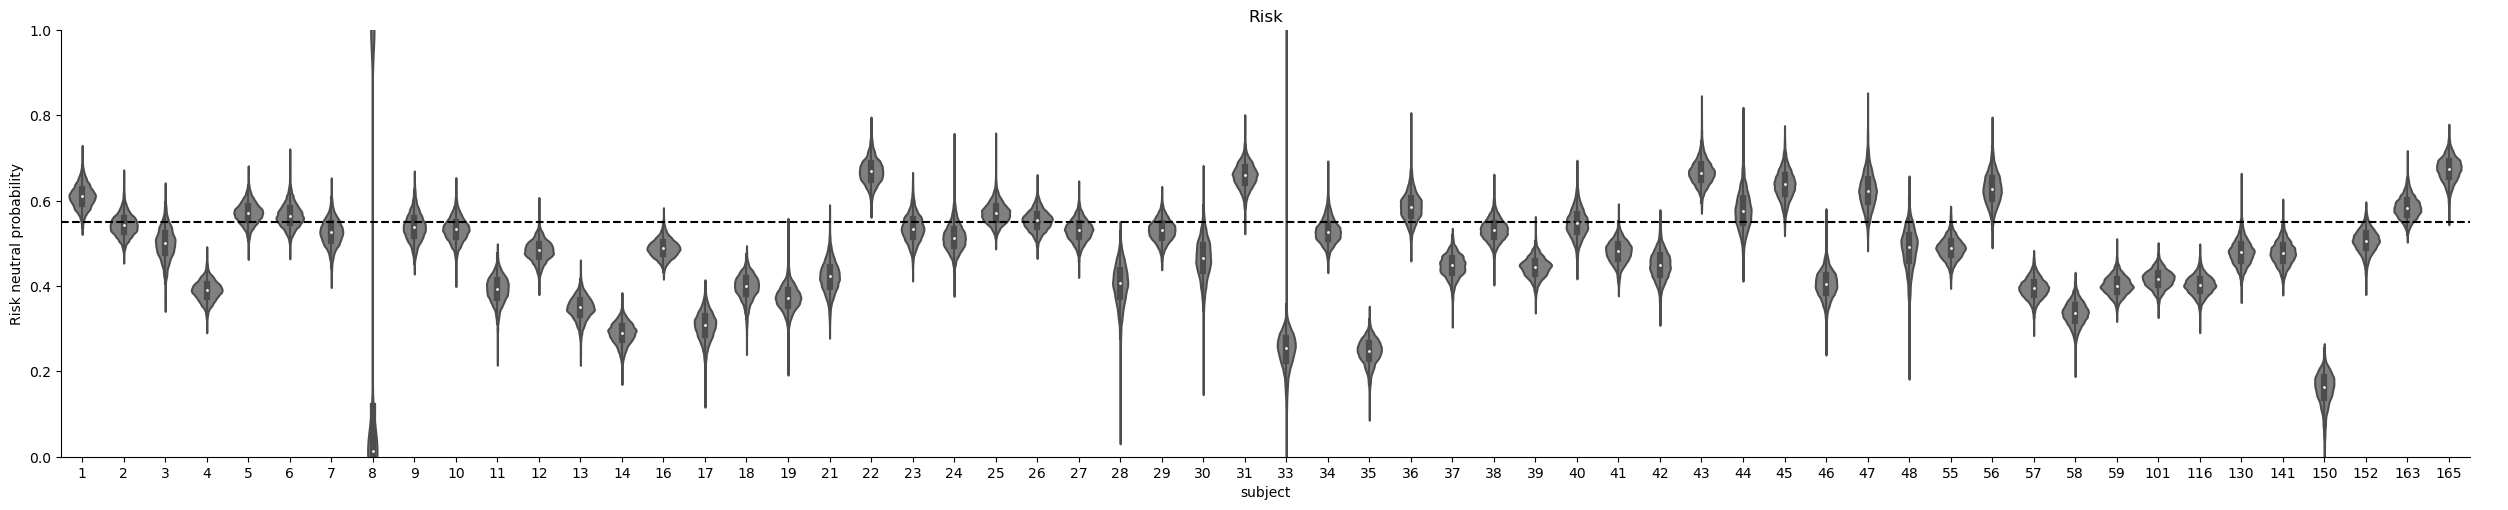

In [25]:
import numpy as np

rnp = np.clip(np.exp(intercept/gamma), 0, 1)

rnp = rnp.stack([1,2])
rnp.columns = ['rnp']

fac = sns.catplot(x='subject', y='rnp', data=rnp.reset_index(), aspect=5., kind='violin', color='gray')
plt.ylim(0, 1)
plt.axhline(.55, c='k', ls='--', label='risk-neutral')
fac.set(title='Risk', ylabel='Risk neutral probability')
fac.add_legend()

/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_51591/48917856.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(rnp.groupby('subject').mean(), bins=25)


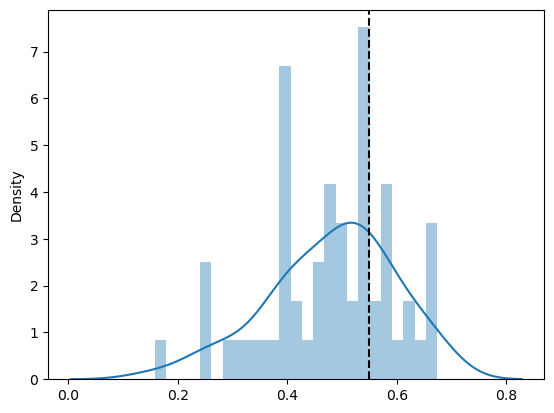

In [26]:
sns.distplot(rnp.groupby('subject').mean(), bins=25)
plt.axvline(.55, c='k', ls='--')

In [27]:
rnp.groupby('subject').mean().to_csv('subjectwise_rnp.tsv', sep='\t')

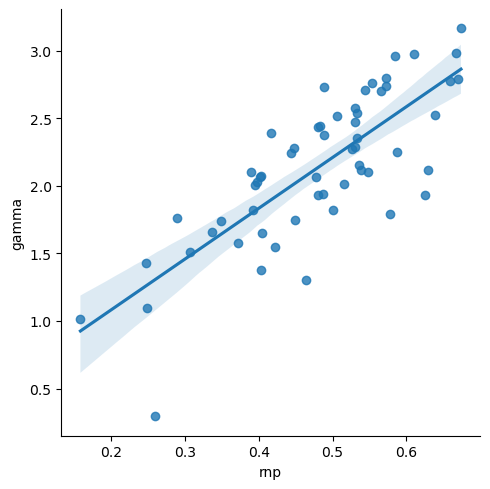

In [28]:
gamma_ = gamma.stack([1, 2]).groupby(['subject']).mean()
gamma_.columns = ['gamma']

rnp_ = rnp.groupby(['subject']).mean()

pars = rnp_.join(gamma_)
sns.lmplot(x='rnp', y='gamma', data=pars)

In [29]:
gamma_.to_csv('subjectwise_gamma.tsv', sep='\t')

In [30]:
pwd

'/Users/mrenke/git/stress_risk/stress_risk/subject_selection'